---
title: "Catalog — build → query → load (intro)"
---

# Catalog intro — build → query → load on a real Sentinel-2 archive

This notebook walks the canonical `geocatalog` flow against a real
Sentinel-2 L2A archive over Lake Tahoe — eight scenes spanning June
2024 pulled from Microsoft Planetary Computer. We:

1. Discover items via STAC, sign their asset URLs.
2. Build a `GeoCatalog` from the signed URLs (one row per scene).
3. Run spatial + temporal queries.
4. Mosaic and time-stack matching rows into `GeoTensor`s.

No synthetic GeoTIFFs, no `tempfile` setup — the catalog flow is the
*only* substrate, and the URLs are real.

In [1]:
import json

import geocatalog as gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from geostack import LAKE_TAHOE_BBOX, LAKE_TAHOE_TILE, load_stac_items

## 1. Discover scenes via STAC

Eight cloud-free Sentinel-2 L2A items over Lake Tahoe in June 2024 —
`load_stac_items` does the search + signing.

In [2]:
items = load_stac_items(
    "sentinel-2-l2a",
    LAKE_TAHOE_BBOX,
    "2024-06-01/2024-07-31",
    tile=LAKE_TAHOE_TILE,
    max_cloud_cover=15,
)
print(f"found {len(items)} S2 L2A items on MGRS tile {LAKE_TAHOE_TILE}")
for it in items[:5]:
    print(f"  {it.id}  cloud_cover={it.properties['eo:cloud_cover']:.2f}%")

found 22 S2 L2A items on MGRS tile 10SGJ
  S2A_MSIL2A_20240729T183921_R070_T10SGJ_20240730T023050  cloud_cover=0.00%
  S2B_MSIL2A_20240614T183919_R070_T10SGJ_20240615T003207  cloud_cover=0.01%
  S2A_MSIL2A_20240709T183921_R070_T10SGJ_20240710T024627  cloud_cover=0.01%
  S2A_MSIL2A_20240629T183921_R070_T10SGJ_20240630T032941  cloud_cover=0.01%
  S2B_MSIL2A_20240604T183919_R070_T10SGJ_20240604T233744  cloud_cover=0.02%


## 2. Build a raster catalog from the signed URLs

`build_raster_catalog` reads each file's bounds (via `rasterio` —
`/vsicurl/` for remote URLs) and a date from the filename via the
`(?P<date>…)` named group. Sentinel-2 product IDs follow the pattern
`S2X_MSIL2A_YYYYMMDDTHHMMSS_…` — we extract the `YYYYMMDD` chunk.

In [3]:
# One asset per scene — pick B04 (Red, 10 m). The catalog stores the
# URL + the metadata; we'll pull pixel data lazily on `load_raster`.
urls = [it.assets["B04"].href for it in items]

catalog = gc.build_raster_catalog(
    urls,
    filename_regex=r".*_(?P<date>\d{8})T\d{6}_.*\.tif",
    target_crs="EPSG:32610",
)
print(f"len(catalog): {len(catalog)}")
print(f"catalog.backend: {catalog.backend!r}")
print(f"catalog.total_bounds: {tuple(round(x, 1) for x in catalog.total_bounds)}")
print(f"catalog.temporal_extent: {catalog.temporal_extent}")

len(catalog): 22
catalog.backend: 'raster'
catalog.total_bounds: (699960.0, 4290240.0, 809760.0, 4400040.0)
catalog.temporal_extent: [2024-06-02 00:00:00, 2024-07-29 23:59:59.999999]


Inspect the underlying `GeoDataFrame` — one row per scene with a
`geometry` column (footprint polygon) and an `IntervalIndex` row
index carrying the time interval.

In [4]:
catalog.gdf[["filepath", "start_time", "end_time"]].head()

,filepath,start_time,end_time
datetime,,,
"[2024-07-29 00:00:00, 2024-07-29 23:59:59.999999]",https://sentinel2l2a01.blob.core.windows.net/s...,2024-07-29,2024-07-29 23:59:59.999999
"[2024-06-14 00:00:00, 2024-06-14 23:59:59.999999]",https://sentinel2l2a01.blob.core.windows.net/s...,2024-06-14,2024-06-14 23:59:59.999999
"[2024-07-09 00:00:00, 2024-07-09 23:59:59.999999]",https://sentinel2l2a01.blob.core.windows.net/s...,2024-07-09,2024-07-09 23:59:59.999999
"[2024-06-29 00:00:00, 2024-06-29 23:59:59.999999]",https://sentinel2l2a01.blob.core.windows.net/s...,2024-06-29,2024-06-29 23:59:59.999999
"[2024-06-04 00:00:00, 2024-06-04 23:59:59.999999]",https://sentinel2l2a01.blob.core.windows.net/s...,2024-06-04,2024-06-04 23:59:59.999999


## 3. Query

Build a `GeoSlice` over the western shore of Lake Tahoe for the
first week of June. Ask the catalog which rows intersect.

In [5]:
# UTM 10N coordinates for the Lake Tahoe AOI:
aoi_bounds_utm = (752000.0, 4320000.0, 760000.0, 4330000.0)
aoi_week1 = gc.GeoSlice(
    bounds=aoi_bounds_utm,
    interval=pd.Interval(
        pd.Timestamp("2024-06-01"), pd.Timestamp("2024-06-07"), closed="both"
    ),
    resolution=(10.0, 10.0),
    crs="EPSG:32610",
)
hits = catalog.query(aoi_week1)
print(f"first-week hits: {len(hits)}")
print(hits.gdf[["start_time", "filepath"]].to_string())

first-week hits: 3
                                                  start_time                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             filepath
datetime                                                                                                                                                                                                                                                                                                                                                                                           

### Cross-CRS query

Same query but with the AOI specified in EPSG:4326. The catalog
reprojects the bbox internally — silent empty-result bugs from
CRS mismatches are caught at the boundary.

In [6]:
aoi_4326 = gc.GeoSlice(
    bounds=LAKE_TAHOE_BBOX,
    interval=aoi_week1.interval,
    resolution=(0.0001, 0.0001),
    crs="EPSG:4326",
)
hits_4326 = catalog.query(aoi_4326)
print(f"same query via EPSG:4326: {len(hits_4326)} hits")

same query via EPSG:4326: 3 hits


## 4. Load a single-scene mosaic

`load_raster` mosaics every catalog row that intersects the slice
into one `GeoTensor`. With one row, this is a windowed read; with
multiple, the merge is controlled by `merge_method`.

mosaic shape: (1, 1000, 800)  dtype=uint16
mosaic crs:   EPSG:32610


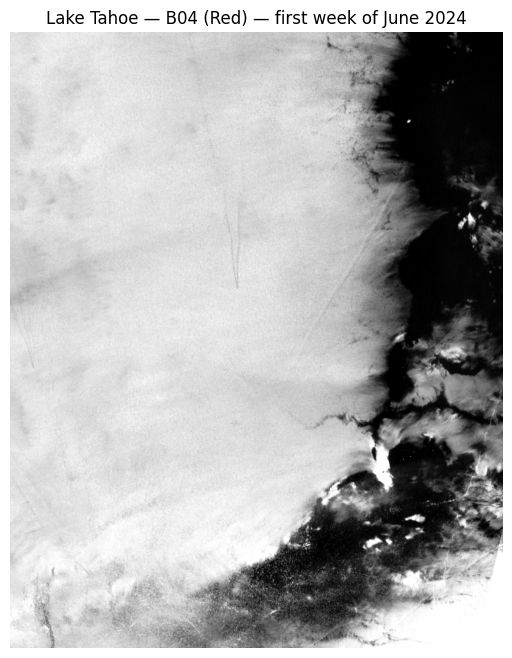

In [7]:
mosaic_week1 = gc.load_raster(catalog, aoi_week1, merge_method="last")
print(f"mosaic shape: {mosaic_week1.values.shape}  dtype={mosaic_week1.values.dtype}")
print(f"mosaic crs:   {mosaic_week1.crs}")

fig, ax = plt.subplots(figsize=(7, 8))
arr = mosaic_week1.values.squeeze()
ax.imshow(arr, cmap="Greys_r", vmin=np.percentile(arr, 2), vmax=np.percentile(arr, 98))
ax.set_title("Lake Tahoe — B04 (Red) — first week of June 2024")
ax.axis("off")
plt.show()

## 5. Time-series stacking

`load_raster_timeseries` walks the catalog day by day and stacks the
daily mosaics along a leading time axis. Over the full eight-week
AOI we get one B04 mosaic per acquisition date.

time-series shape: (22, 1, 1000, 800)
  T = 22 distinct acquisition dates


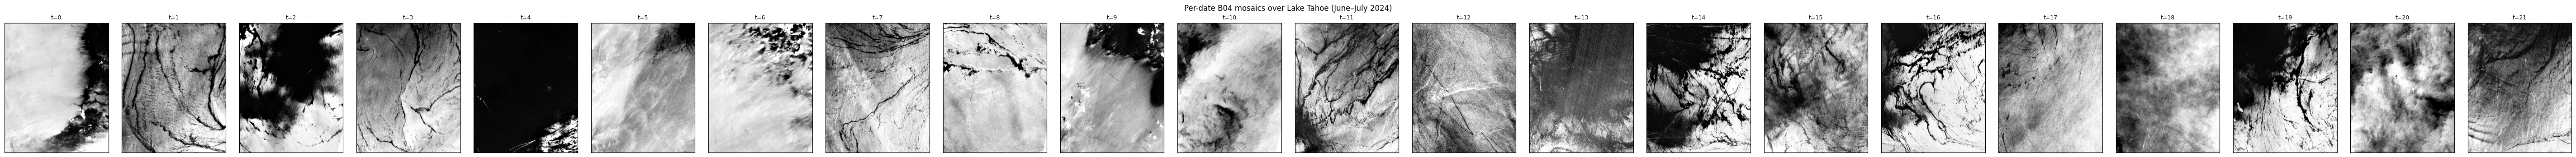

In [8]:
aoi_full = gc.GeoSlice(
    bounds=aoi_bounds_utm,
    interval=pd.Interval(
        pd.Timestamp("2024-06-01"), pd.Timestamp("2024-07-31"), closed="both"
    ),
    resolution=(10.0, 10.0),
    crs="EPSG:32610",
)
series = gc.load_raster_timeseries(catalog, aoi_full)
print(f"time-series shape: {series.values.shape}")
print(f"  T = {series.values.shape[0]} distinct acquisition dates")

T = series.values.shape[0]
fig, axes = plt.subplots(1, T, figsize=(2.6 * T, 3.5))
for i, ax in enumerate(np.atleast_1d(axes)):
    arr = series.values[i].squeeze()
    ax.imshow(
        arr,
        cmap="Greys_r",
        vmin=np.percentile(arr, 2),
        vmax=np.percentile(arr, 98),
    )
    ax.set_title(f"t={i}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Per-date B04 mosaics over Lake Tahoe (June–July 2024)")
plt.tight_layout()
plt.show()

## 6. `get_config()`

Every catalog returns a JSON-serialisable summary — handy for
logging and reproducibility audits.

In [9]:
print(json.dumps(catalog.get_config(), indent=2))

{
  "backend": "raster",
  "len": 22,
  "crs": "EPSG:32610"
}


## Where next

- **[02_backends](02_backends.ipynb)** — raster (here), xarray, and
  vector catalog backends on heterogeneous real data.
- **[03_set_algebra](03_set_algebra.ipynb)** — `query` / `intersect` /
  `union` over multiple real catalogs.
- **[04_duckdb](04_duckdb.ipynb)** — `DuckDBGeoCatalog` against the
  Overture buildings GeoParquet (billions of rows).
- **[05_patching_bridge](05_patching_bridge.ipynb)** — `CatalogDomain`
  plugs the catalog into the same `SpatialPatcher` pipeline from the
  patching deep dives.